# Player Engagement Prediction and Persona Segmentation

## Objective

This notebook uses the Kaggle **Predict Online Gaming Behavior Dataset** to:

1. Analyse online player behaviour
2. Create player personas using clustering
3. Predict `EngagementLevel` using machine learning
4. Validate model performance
5. Identify the strongest drivers of player engagement
6. Convert model outputs into business recommendations for gaming/publishing teams

This project is aligned to gaming analytics, publishing insights, player segmentation and model validation responsibilities.


## 1. Import Libraries

In [1]:
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_validate, StratifiedKFold
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

pd.set_option("display.max_columns", 100)


## 2. Load Kaggle Dataset

Dataset slug:

```bash
rabieelkharoua/predict-online-gaming-behavior-dataset
```

The code below automatically loads the first CSV file from the `data/` folder.


In [2]:
DATA_DIR = Path("../data")
csv_files = list(DATA_DIR.glob("*.csv"))

if not csv_files:
    raise FileNotFoundError(
        "No CSV file found in ../data. "
        "Download the Kaggle dataset and place the CSV file inside the data folder."
    )

csv_path = csv_files[0]
print(f"Loading dataset from: {csv_path}")

df = pd.read_csv(csv_path)
df.head()


Loading dataset from: ..\data\online_gaming_behavior_dataset.csv


,PlayerID,Age,Gender,Location,GameGenre,PlayTimeHours,InGamePurchases,GameDifficulty,SessionsPerWeek,AvgSessionDurationMinutes,PlayerLevel,AchievementsUnlocked,EngagementLevel
0,9000,43,Male,Other,Strategy,16.271119,0,Medium,6,108,79,25,Medium
1,9001,29,Female,USA,Strategy,5.525961,0,Medium,5,144,11,10,Medium
2,9002,22,Female,USA,Sports,8.223755,0,Easy,16,142,35,41,High
3,9003,35,Male,USA,Action,5.265351,1,Easy,9,85,57,47,Medium
4,9004,33,Male,Europe,Action,15.531945,0,Medium,2,131,95,37,Medium


In [3]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40034 entries, 0 to 40033
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   PlayerID                   40034 non-null  int64  
 1   Age                        40034 non-null  int64  
 2   Gender                     40034 non-null  object 
 3   Location                   40034 non-null  object 
 4   GameGenre                  40034 non-null  object 
 5   PlayTimeHours              40034 non-null  float64
 6   InGamePurchases            40034 non-null  int64  
 7   GameDifficulty             40034 non-null  object 
 8   SessionsPerWeek            40034 non-null  int64  
 9   AvgSessionDurationMinutes  40034 non-null  int64  
 10  PlayerLevel                40034 non-null  int64  
 11  AchievementsUnlocked       40034 non-null  int64  
 12  EngagementLevel            40034 non-null  object 
dtypes: float64(1), int64(7), object(5)
memory usag

In [4]:
df.describe(include="all").T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
PlayerID,40034.0,NaN,NaN,NaN,29016.5,11556.964675,9000.0,19008.25,29016.5,39024.75,49033.0
Age,40034.0,NaN,NaN,NaN,31.992531,10.043227,15.0,23.0,32.0,41.0,49.0
Gender,40034,2,Male,23959,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Location,40034,4,USA,16000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
GameGenre,40034,5,Sports,8048,NaN,NaN,NaN,NaN,NaN,NaN,NaN
PlayTimeHours,40034.0,NaN,NaN,NaN,12.024365,6.914638,0.000115,6.067501,12.008002,17.963831,23.999592
InGamePurchases,40034.0,NaN,NaN,NaN,0.200854,0.400644,0.0,0.0,0.0,0.0,1.0
GameDifficulty,40034,3,Easy,20015,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SessionsPerWeek,40034.0,NaN,NaN,NaN,9.471774,5.763667,0.0,4.0,9.0,14.0,19.0
AvgSessionDurationMinutes,40034.0,NaN,NaN,NaN,94.792252,49.011375,10.0,52.0,95.0,137.0,179.0


## 3. Basic Data Quality Checks

In [6]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

missing_summary = df.isna().sum().sort_values(ascending=False)
missing_summary[missing_summary > 0]


Rows: 40034
Columns: 13


Series([], dtype: int64)

In [7]:
duplicate_players = df["PlayerID"].duplicated().sum()
print("Duplicate PlayerID records:", duplicate_players)


Duplicate PlayerID records: 0


## 4. Target Variable Analysis

The target column is:

```text
EngagementLevel
```

This is a multi-class classification target with values such as Low, Medium and High.


,player_count,percentage
EngagementLevel,,
Medium,19374,48.39
High,10336,25.82
Low,10324,25.79


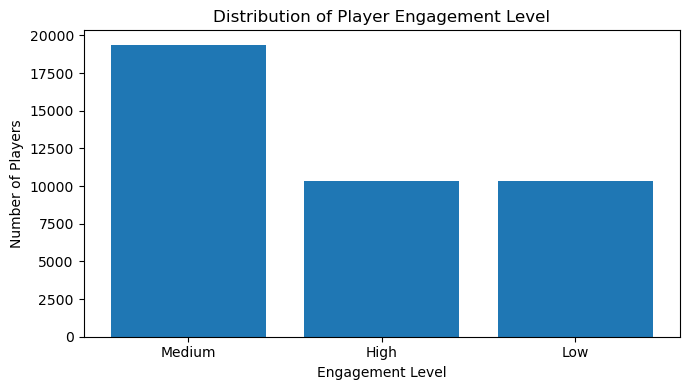

In [8]:
target = "EngagementLevel"

engagement_counts = df[target].value_counts()
engagement_pct = (df[target].value_counts(normalize=True) * 100).round(2)

display(pd.DataFrame({
    "player_count": engagement_counts,
    "percentage": engagement_pct
}))

plt.figure(figsize=(7, 4))
plt.bar(engagement_counts.index.astype(str), engagement_counts.values)
plt.title("Distribution of Player Engagement Level")
plt.xlabel("Engagement Level")
plt.ylabel("Number of Players")
plt.tight_layout()
plt.savefig("../images/engagement_distribution.png", dpi=150)
plt.show()


## 5. Exploratory Data Analysis

### Engagement by Game Genre


In [9]:
genre_engagement = (
    df.groupby(["GameGenre", "EngagementLevel"])
    .size()
    .reset_index(name="player_count")
)

genre_pivot = genre_engagement.pivot(
    index="GameGenre",
    columns="EngagementLevel",
    values="player_count"
).fillna(0)

genre_pivot_pct = genre_pivot.div(genre_pivot.sum(axis=1), axis=0).round(3)
genre_pivot_pct


EngagementLevel,High,Low,Medium
GameGenre,,,
Action,0.257,0.256,0.487
RPG,0.250,0.264,0.486
Simulation,0.264,0.262,0.475
Sports,0.259,0.258,0.483
Strategy,0.262,0.250,0.488


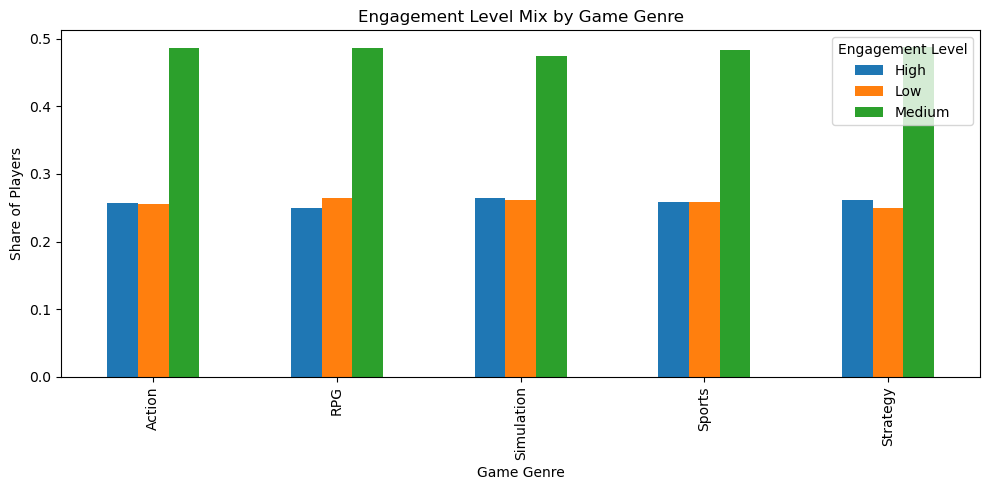

In [10]:
genre_pivot_pct.plot(kind="bar", figsize=(10, 5))
plt.title("Engagement Level Mix by Game Genre")
plt.xlabel("Game Genre")
plt.ylabel("Share of Players")
plt.legend(title="Engagement Level")
plt.tight_layout()
plt.savefig("../images/engagement_by_genre.png", dpi=150)
plt.show()


### Engagement by In-Game Purchases

In [11]:
purchase_engagement = (
    df.groupby(["InGamePurchases", "EngagementLevel"])
    .size()
    .reset_index(name="player_count")
)

purchase_pivot = purchase_engagement.pivot(
    index="InGamePurchases",
    columns="EngagementLevel",
    values="player_count"
).fillna(0)

purchase_pivot_pct = purchase_pivot.div(purchase_pivot.sum(axis=1), axis=0).round(3)
purchase_pivot_pct


EngagementLevel,High,Low,Medium
InGamePurchases,,,
0,0.256,0.259,0.485
1,0.265,0.253,0.481


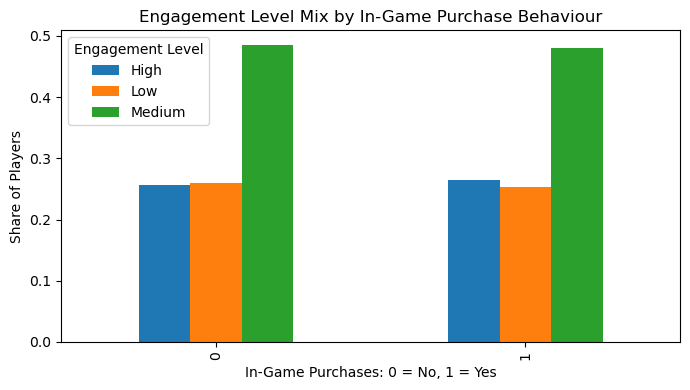

In [12]:
purchase_pivot_pct.plot(kind="bar", figsize=(7, 4))
plt.title("Engagement Level Mix by In-Game Purchase Behaviour")
plt.xlabel("In-Game Purchases: 0 = No, 1 = Yes")
plt.ylabel("Share of Players")
plt.legend(title="Engagement Level")
plt.tight_layout()
# plt.savefig("../images/engagement_by_purchases.png", dpi=150)
plt.show()


### Numeric Feature Comparison by Engagement Level

In [13]:
numeric_features = [
    "Age",
    "PlayTimeHours",
    "SessionsPerWeek",
    "AvgSessionDurationMinutes",
    "PlayerLevel",
    "AchievementsUnlocked"
]

df.groupby("EngagementLevel")[numeric_features].mean().round(2)


,Age,PlayTimeHours,SessionsPerWeek,AvgSessionDurationMinutes,PlayerLevel,AchievementsUnlocked
EngagementLevel,,,,,,
High,31.92,12.07,14.25,131.92,50.82,25.10
Low,31.90,12.10,4.53,66.88,46.10,22.66
Medium,32.08,11.96,9.55,89.86,50.93,25.22


## 6. Player Persona Segmentation with K-Means

Segmentation is unsupervised. We do **not** use the target column `EngagementLevel` for clustering.

We use behavioural and progression features to create player personas.


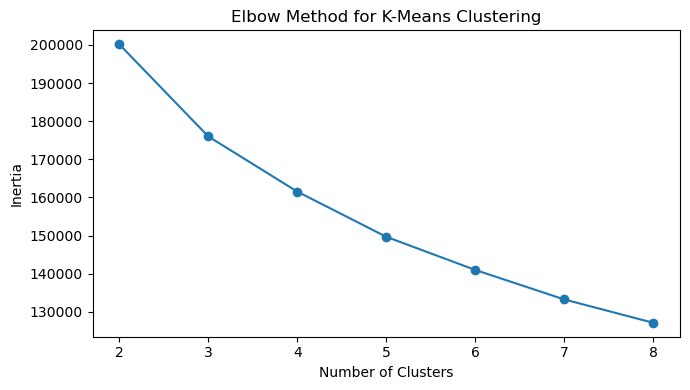

In [14]:
segmentation_features = [
    "PlayTimeHours",
    "SessionsPerWeek",
    "AvgSessionDurationMinutes",
    "PlayerLevel",
    "AchievementsUnlocked",
    "InGamePurchases"
]

X_seg = df[segmentation_features].copy()

scaler = StandardScaler()
X_seg_scaled = scaler.fit_transform(X_seg)

# Check inertia for possible cluster values
inertia = []
cluster_range = range(2, 9)

for k in cluster_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_seg_scaled)
    inertia.append(km.inertia_)

plt.figure(figsize=(7, 4))
plt.plot(list(cluster_range), inertia, marker="o")
plt.title("Elbow Method for K-Means Clustering")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.tight_layout()
plt.savefig("../images/kmeans_elbow.png", dpi=150)
plt.show()


In [18]:
# Choose 4 segments for business interpretability
## Choose 3 segments based on elbow method
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df["PlayerSegment"] = kmeans.fit_predict(X_seg_scaled)

segment_summary = (
    df.groupby("PlayerSegment")[segmentation_features]
    .mean()
    .round(2)
)

segment_engagement = (
    df.groupby(["PlayerSegment", "EngagementLevel"])
    .size()
    .reset_index(name="player_count")
    .pivot(index="PlayerSegment", columns="EngagementLevel", values="player_count")
    .fillna(0)
)

segment_engagement_pct = segment_engagement.div(segment_engagement.sum(axis=1), axis=0).round(3)

display(segment_summary)
display(segment_engagement_pct)


,PlayTimeHours,SessionsPerWeek,AvgSessionDurationMinutes,PlayerLevel,AchievementsUnlocked,InGamePurchases
PlayerSegment,,,,,,
0,19.27,9.29,96.07,47.51,24.74,0.0
1,8.03,9.53,93.94,76.96,24.89,0.0
2,11.94,9.53,94.49,50.03,24.53,1.0
3,7.30,9.58,94.34,23.74,23.89,0.0


EngagementLevel,High,Low,Medium
PlayerSegment,,,
0,0.255,0.264,0.481
1,0.264,0.229,0.507
2,0.265,0.253,0.481
3,0.250,0.284,0.466


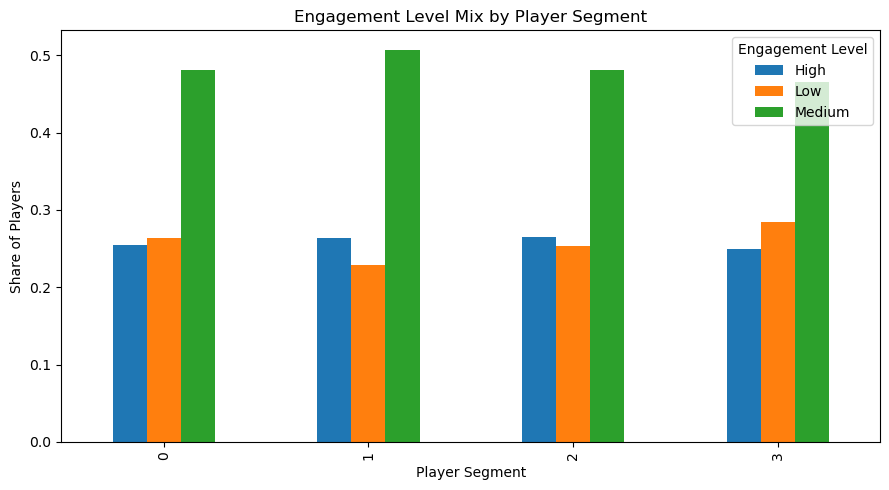

In [19]:
segment_engagement_pct.plot(kind="bar", figsize=(9, 5))
plt.title("Engagement Level Mix by Player Segment")
plt.xlabel("Player Segment")
plt.ylabel("Share of Players")
plt.legend(title="Engagement Level")
plt.tight_layout()
plt.savefig("../images/engagement_by_segment.png", dpi=150)
plt.show()


### Persona Interpretation Guide

The K-Means clustering model produced four player personas. 
* Segment 0 represents Highly Active Non-Payers, with the highest playtime but no purchase behaviour.
* Segment 1 represents Efficient Progressors, who show the highest player level despite lower playtime.
* Segment 2 represents Purchase-Driven Players, the only group with in-game purchase behaviour and therefore important for monetisation and lifetime value.
* Segment 3 represents Casual Early-Stage Players, with the lowest playtime and lowest progression level, making them suitable for onboarding and reactivation strategies.

Although all segments contain a high proportion of medium-engagement users, the clusters are useful because they separate players by behavioural and commercial patterns such as playtime, progression and purchase behaviour. These personas can support targeted retention, monetisation and player experience strategies.


## 7. Prepare Data for Engagement Prediction

Target:

```text
EngagementLevel
```

Features:

```text
Age, Gender, Location, GameGenre, PlayTimeHours, InGamePurchases,
GameDifficulty, SessionsPerWeek, AvgSessionDurationMinutes, PlayerLevel,
AchievementsUnlocked, PlayerSegment
```


In [20]:
model_features = [
    "Age",
    "Gender",
    "Location",
    "GameGenre",
    "PlayTimeHours",
    "InGamePurchases",
    "GameDifficulty",
    "SessionsPerWeek",
    "AvgSessionDurationMinutes",
    "PlayerLevel",
    "AchievementsUnlocked",
    "PlayerSegment"
]

X = df[model_features].copy()
y = df["EngagementLevel"].copy()

categorical_features = [
    "Gender",
    "Location",
    "GameGenre",
    "GameDifficulty",
    "PlayerSegment"
]

numeric_features = [
    "Age",
    "PlayTimeHours",
    "InGamePurchases",
    "SessionsPerWeek",
    "AvgSessionDurationMinutes",
    "PlayerLevel",
    "AchievementsUnlocked"
]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training rows:", X_train.shape[0])
print("Testing rows:", X_test.shape[0])


Training rows: 32027
Testing rows: 8007


## 8. Train and Evaluate Models

We train three models:

1. Logistic Regression — interpretable baseline
2. Random Forest — non-linear model with feature importance
3. Gradient Boosting — boosted tree model for stronger predictive performance


In [21]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight="balanced"),
    "Random Forest": RandomForestClassifier(
        n_estimators=250,
        max_depth=10,
        min_samples_leaf=10,
        random_state=42,
        class_weight="balanced"
    ),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42)
}

results = []

trained_models = {}

for model_name, model in models.items():
    pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    pipeline.fit(X_train, y_train)

    y_pred = pipeline.predict(X_test)
    y_proba = pipeline.predict_proba(X_test)

    metrics = {
        "model": model_name,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision_macro": precision_score(y_test, y_pred, average="macro"),
        "recall_macro": recall_score(y_test, y_pred, average="macro"),
        "f1_macro": f1_score(y_test, y_pred, average="macro"),
        "precision_weighted": precision_score(y_test, y_pred, average="weighted"),
        "recall_weighted": recall_score(y_test, y_pred, average="weighted"),
        "f1_weighted": f1_score(y_test, y_pred, average="weighted"),
        "roc_auc_ovr": roc_auc_score(y_test, y_proba, multi_class="ovr")
    }

    results.append(metrics)
    trained_models[model_name] = pipeline

results_df = pd.DataFrame(results).sort_values("f1_macro", ascending=False)
results_df.round(3)


,model,accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted,roc_auc_ovr
2,Gradient Boosting,0.904,0.906,0.892,0.899,0.904,0.904,0.903,0.942
1,Random Forest,0.870,0.863,0.871,0.867,0.871,0.870,0.870,0.937
0,Logistic Regression,0.786,0.778,0.808,0.787,0.799,0.786,0.786,0.913


### Best Model Evaluation

In [22]:
best_model_name = results_df.iloc[0]["model"]
best_model = trained_models[best_model_name]

print("Best model:", best_model_name)

best_pred = best_model.predict(X_test)

print(classification_report(y_test, best_pred))


Best model: Gradient Boosting
              precision    recall  f1-score   support

        High       0.91      0.87      0.89      2067
         Low       0.91      0.86      0.89      2065
      Medium       0.90      0.94      0.92      3875

    accuracy                           0.90      8007
   macro avg       0.91      0.89      0.90      8007
weighted avg       0.90      0.90      0.90      8007



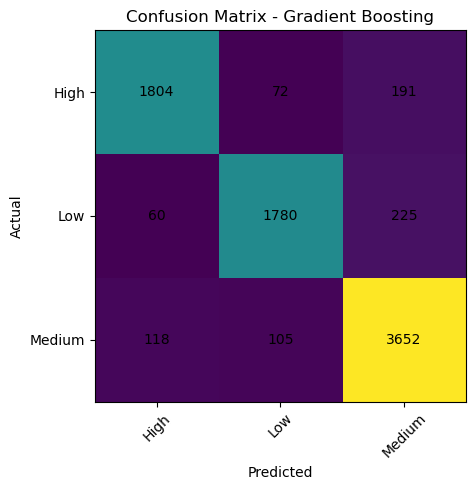

In [23]:
labels = sorted(y_test.unique())
cm = confusion_matrix(y_test, best_pred, labels=labels)

plt.figure(figsize=(6, 5))
plt.imshow(cm)
plt.title(f"Confusion Matrix - {best_model_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.xticks(range(len(labels)), labels, rotation=45)
plt.yticks(range(len(labels)), labels)

for i in range(len(labels)):
    for j in range(len(labels)):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.tight_layout()
plt.savefig("../images/confusion_matrix.png", dpi=150)
plt.show()


## 9. Cross-Validation

Cross-validation checks whether model performance is stable across multiple splits, not just one train/test split.


In [24]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_pipeline = best_model

scoring = {
    "accuracy": "accuracy",
    "precision_macro": "precision_macro",
    "recall_macro": "recall_macro",
    "f1_macro": "f1_macro"
}

cv_scores = cross_validate(
    cv_pipeline,
    X,
    y,
    cv=cv,
    scoring=scoring,
    return_train_score=False
)

cv_summary = pd.DataFrame({
    metric: [scores.mean(), scores.std()]
    for metric, scores in cv_scores.items()
    if metric.startswith("test_")
}, index=["mean", "std"]).T

cv_summary.round(3)


,mean,std
test_accuracy,0.908,0.001
test_precision_macro,0.910,0.002
test_recall_macro,0.896,0.002
test_f1_macro,0.903,0.002


## 10. Feature Importance

Since the best model is Gradient Boosting, we use its feature importance to understand which variables are most useful for predicting EngagementLevel.

In [26]:
explain_model_name = "Gradient Boosting"
explain_model = trained_models[explain_model_name]

# Get feature names after preprocessing
feature_names = explain_model.named_steps["preprocessor"].get_feature_names_out()

# Extract feature importance from Gradient Boosting model
importances = explain_model.named_steps["model"].feature_importances_

feature_importance = (
    pd.DataFrame({
        "feature": feature_names,
        "importance": importances
    })
    .sort_values("importance", ascending=False)
    .head(15)
)

feature_importance

,feature,importance
4,num__AvgSessionDurationMinutes,0.497043
3,num__SessionsPerWeek,0.485211
5,num__PlayerLevel,0.008100
6,num__AchievementsUnlocked,0.008035
1,num__PlayTimeHours,0.001195
0,num__Age,0.000238
16,cat__GameGenre_Sports,0.000030
23,cat__PlayerSegment_2,0.000025
12,cat__Location_USA,0.000022
13,cat__GameGenre_Action,0.000022


The feature importance chart shows that `AvgSessionDurationMinutes` and `SessionsPerWeek` dominate the model’s decision-making. This means the model is primarily using session depth and weekly play frequency to separate Low, Medium and High engagement players.


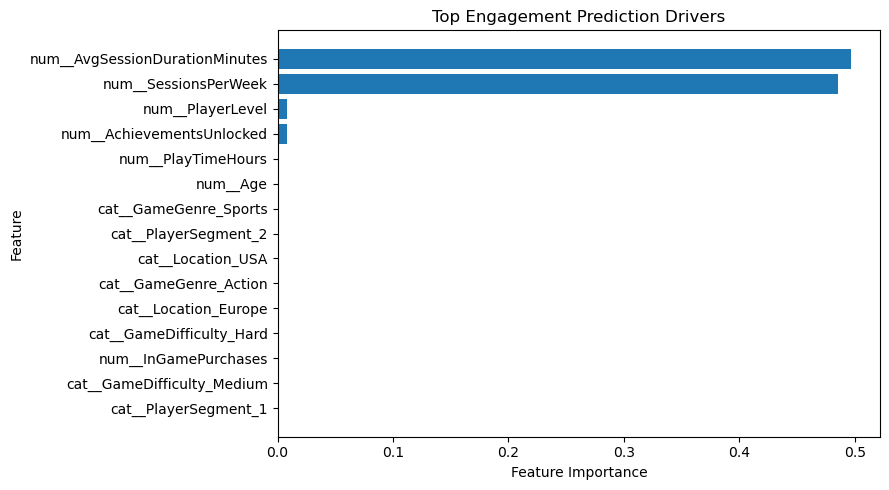

In [27]:
plt.figure(figsize=(9, 5))
plt.barh(feature_importance["feature"][::-1], feature_importance["importance"][::-1])
plt.title("Top Engagement Prediction Drivers")
plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.tight_layout()

plt.show()


## 11. Business Insights and Recommendations

The Gradient Boosting model was the best-performing model for predicting player engagement level. Based on the feature importance output, the strongest engagement prediction drivers are:

1. `AvgSessionDurationMinutes`
2. `SessionsPerWeek`
3. `PlayerLevel`
4. `AchievementsUnlocked`

This shows that player engagement is mainly driven by **how often players play** and **how long they stay in each session**. Progression-related variables such as player level and achievements also contribute, but they are much less influential than session duration and session frequency.

### Key Insights

1. **Average session duration is the strongest engagement driver**  
   Players who spend more time in each session are more likely to be classified into stronger engagement groups. This suggests that session depth is a key signal of player interest.

2. **Sessions per week is almost equally important**  
   Frequent weekly activity is another major indicator of engagement. Players who return regularly are more likely to show stronger engagement patterns.

3. **Progression matters, but less than activity behaviour**  
   Player level and achievements unlocked have some predictive value, but they are not as influential as session duration and weekly session frequency.

4. **Purchasing behaviour is not a major engagement predictor in this dataset**  
   `InGamePurchases` has low feature importance, meaning purchases alone do not explain engagement level strongly. Players can be highly engaged even without making purchases.

5. **Player personas are useful for business interpretation**  
   The segmentation output created four useful behavioural groups: Highly Active Non-Payers, Efficient Progressors, Purchase-Driven Players, and Casual Early-Stage Players. These personas can help create more targeted engagement and retention strategies.

### Recommendations

1. **Increase session depth through stronger in-game experiences**  
   Engagement is driven more by session duration and session frequency than by total playtime.

2. **Encourage regular weekly play**  
   Since sessions per week is highly important, use weekly challenges, login rewards, limited-time events and personalised reminders to encourage players to return more frequently.

3. **Target Casual Early-Stage Players with onboarding support**  
   Segment 3 has the lowest playtime and lowest player level. This group may benefit from better tutorials, early rewards, beginner missions and reactivation campaigns.

4. **Convert Highly Active Non-Payers carefully**  
   Segment 0 has the highest playtime but no in-game purchases. These players are already engaged, so they could be targeted with low-friction offers such as starter bundles, cosmetic rewards, battle-pass trials or personalised discounts.

5. **Retain Purchase-Driven Players with loyalty actions**  
   Segment 2 is the only purchase-driven group. This segment should receive premium content recommendations, loyalty rewards and personalised offers to improve retention and lifetime value.

6. **Use the model as a monitoring tool**  
   The model can be used to regularly score players into Low, Medium and High engagement groups. EA-style publishing teams could use this to monitor engagement shifts, identify at-risk players and evaluate whether campaigns are improving player behaviour.

7. **Track model quality over time**  
   Continue monitoring F1-score, recall and class-level performance, especially for Low and High engagement groups. This helps ensure the model remains accurate as player behaviour changes over time.

## 12. Final Portfolio Summary

This project demonstrates how gaming behaviour data can support player persona segmentation and engagement prediction. It uses a synthetic gaming dataset from Kaggle, applies clustering and multi-class classification, validates model performance and converts data science outputs into business recommendations for player engagement and retention.
